# Task 1

### 1a Do you observe the same thing now for the maximal reaction activities?
- No, the maximal reaction activities are not generally equal along a linear pathway. These values show the maximum capacity of each reaction, not the actual flux through it. Actual fluxes must satisfy mass balance, but maximal activities do not have to be equal.

### 1b  identify what these grey arrow values are and how their meaning differs. 
- Grey arrows can show either 0 or nd. A value of 0 means the reaction has a measured maximal activity of zero. nd means there is no data available for that reaction.

# Imports and model

In [1]:
#imports
import cobra
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from sys import stdout

In [2]:

MODEL_FILE = "e_coli_core-1.json"
EXPRESSION_FILE = "KEN3170_Assignment_2026_e_coli_core_expression.csv"

#load the model
model = cobra.io.load_json_model(MODEL_FILE)    

temp_model = model.copy()

#load the expression data
expression = pd.read_csv(EXPRESSION_FILE)
expression = expression.iloc[:, :2].copy()
expression.columns = ["reaction_id", "max_activity"]
expression["reaction_id"] = expression["reaction_id"].astype(str).str.strip()
expression["max_activity"] = pd.to_numeric(expression["max_activity"],errors="raise")

expression.head()

,reaction_id,max_activity
0,PFK,13.1
1,PFL,0.0
2,PGI,11.1
3,PGK,24.0
4,PGL,7.3


# Task 2

In [3]:
# Update the bounds in the model with value from the expression file 
# Checking to see if the reactions in the expression file line up with the model provided 
# react_list = []
# for i in model.reactions:
#     react_list.append(i.id)
# print(f"No. of reactions in Model       : {len(react_list)}")
# print(f"No. of reactions in Expression  : {len(expression)}")

for index, row in expression.iterrows():
    #  Find the reactions in the model
    if model.reactions.get_by_id(row["reaction_id"]):

        #  Change the values based on reversibility
        if model.reactions.get_by_id(row["reaction_id"]).reversibility:
            model.reactions.get_by_id(row["reaction_id"]).lower_bound = -row["max_activity"]
            model.reactions.get_by_id(row["reaction_id"]).upper_bound = row["max_activity"]
        else:
            model.reactions.get_by_id(row["reaction_id"]).lower_bound = 0
            model.reactions.get_by_id(row["reaction_id"]).upper_bound = row["max_activity"]

print("---------------------\nVALUES UPDATED\n------------------- ")


---------------------
VALUES UPDATED
------------------- 


In [4]:

# Change the lower bound to deafult value for the glucose exchange reaction (“EX_glc__D_e”)
print(f"EX_glc__D_e initial Lowerbound:{model.reactions.EX_glc__D_e.lower_bound}")
model.reactions.EX_glc__D_e.lower_bound = -1000 
print(f"Changed to default Lowerbound:{model.reactions.EX_glc__D_e.lower_bound}")


# Check the atpm reactions bounds 
print(f"\nATPM reactions bounds same? : {model.reactions.ATPM.lower_bound == temp_model.reactions.ATPM.lower_bound}")

EX_glc__D_e initial Lowerbound:-10.0
Changed to default Lowerbound:-1000

ATPM reactions bounds same? : True


Output for task 2 printed below
- First table is all reactions changed using values from the provided csv file
- Second table is all the reactions involved in the model

In [5]:
comparison = []

# Loop through all reactions in the updated model
for rxn in model.reactions:
    temp_rxn = temp_model.reactions.get_by_id(rxn.id)
    
    # Check if bounds are different
    lb_changed = rxn.lower_bound != temp_rxn.lower_bound
    ub_changed = rxn.upper_bound != temp_rxn.upper_bound
    is_changed = "Yes" if (lb_changed or ub_changed) else "No"
    
    comparison.append({
        "Reaction ID": rxn.id,
        "Initial LB": temp_rxn.lower_bound,
        "Initial UB": temp_rxn.upper_bound,
        "Updated LB": rxn.lower_bound,
        "Updated UB": rxn.upper_bound,
        "Changed": is_changed
    })

# Convert to DataFrame
comp_df = pd.DataFrame(comparison)

pd.set_option("display.max_rows", 100)
print("changed columns only")
display(comp_df[comp_df["Changed"]=="Yes"])
print("\n all reactions printed below")
display(comp_df)


changed columns only


,Reaction ID,Initial LB,Initial UB,Updated LB,Updated UB,Changed
0,PFK,0.0,1000.0,0.00,13.10,Yes
1,PFL,0.0,1000.0,0.00,0.00,Yes
2,PGI,-1000.0,1000.0,-11.10,11.10,Yes
3,PGK,-1000.0,1000.0,-24.00,24.00,Yes
4,PGL,0.0,1000.0,0.00,7.30,Yes
5,ACALD,-1000.0,1000.0,-0.00,0.00,Yes
6,AKGt2r,-1000.0,1000.0,-0.00,0.00,Yes
7,PGM,-1000.0,1000.0,-21.70,21.70,Yes
8,PIt2r,-1000.0,1000.0,-5.20,5.20,Yes
9,ALCD2x,-1000.0,1000.0,-0.00,0.00,Yes



 all reactions printed below


,Reaction ID,Initial LB,Initial UB,Updated LB,Updated UB,Changed
0,PFK,0.00,1000.0,0.00,13.10,Yes
1,PFL,0.00,1000.0,0.00,0.00,Yes
2,PGI,-1000.00,1000.0,-11.10,11.10,Yes
3,PGK,-1000.00,1000.0,-24.00,24.00,Yes
4,PGL,0.00,1000.0,0.00,7.30,Yes
5,ACALD,-1000.00,1000.0,-0.00,0.00,Yes
6,AKGt2r,-1000.00,1000.0,-0.00,0.00,Yes
7,PGM,-1000.00,1000.0,-21.70,21.70,Yes
8,PIt2r,-1000.00,1000.0,-5.20,5.20,Yes
9,ALCD2x,-1000.00,1000.0,-0.00,0.00,Yes


*END OF Output from the 2nd task*

## Task 3


In [6]:
# call FBA biomass optimization (EX_glc__D_e lower bound is -1000)
model_fba_glc1000 = model.copy()
sol_3a = model_fba_glc1000.optimize()
print(f"Task 3a - Maximal biomass production rate: {sol_3a.objective_value:.4f} 1/h")


# update gluscose lower bound to -5 
model_fba_glc5 = model.copy()
model_fba_glc5.reactions.get_by_id('EX_glc__D_e').lower_bound = -5.0


# perform FBA optimization with new glucose lower bound
sol_3c = model_fba_glc5.optimize()
print(f"Task 3c - Maximal biomass production rate (with 5 mmol/gDW/h cap): {sol_3c.objective_value:.4f} 1/h")

Task 3a - Maximal biomass production rate: 0.8733 1/h
Task 3c - Maximal biomass production rate (with 5 mmol/gDW/h cap): 0.4156 1/h


## 3.b
Since the initial glucose flux bounds were capped at [-10, 1000], the intake of the glucose into the system was capped at 10mmol/gDW/h. However updating the lower bound to -1000, meant that the system now has has abundance on glucose availability and isn't placing a binding constraint onto the system.

## 3.c
With expression constraints only, maximal biomass rate was 0.8733/h; but with lowered glucose intake (capped at 5 mmol/gDW/h) the rate drops to 0.4156/h. Therefore the availablity of glucose becomes a binding constraint now.

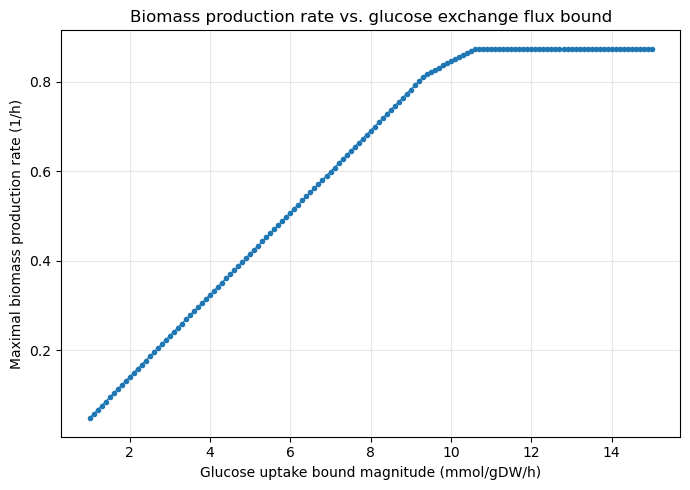

In [7]:
sweep_model = model.copy()  # last updated at task2

glc_uptake_magnitudes = np.round(np.arange(1.0, 15.0 + 1e-9, 0.1), 2)  # magnitude of uptake (mmol/gDW/h)
biomass_rates = []

for glc in glc_uptake_magnitudes:
    sweep_model.reactions.EX_glc__D_e.lower_bound = -glc  # uptake is negative flux by convention
    sol = sweep_model.optimize()
    biomass_rates.append(sol.objective_value)

plt.figure(figsize=(7, 5))
plt.plot(glc_uptake_magnitudes, biomass_rates, marker='o', markersize=3, linewidth=1)
plt.xlabel('Glucose uptake bound magnitude (mmol/gDW/h)')
plt.ylabel('Maximal biomass production rate (1/h)')
plt.title('Biomass production rate vs. glucose exchange flux bound')
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

## 4b
No, growth doesn't increase indefinitely. Glucose availability is the binding
constraint on the system up to roughly a -10 to -11 lower bound. Beyond that
point, additional glucose no longer increases biomass production — some other
capacity in the network (e.g. an oxygen-dependent respiratory reaction) becomes
the new binding constraint instead, and the maximal biomass rate plateaus.